<a href="https://colab.research.google.com/github/zain4cs/customer-churn-prediction-ml/blob/main/Telecom_Cutomer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print("Churn Customer")
print(df['Churn'].value_counts())

Churn Customer
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
print("Percantage!")
print(df['Churn'].value_counts(normalize=True)*100)

Percantage!
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Graph 1: Churn Count**

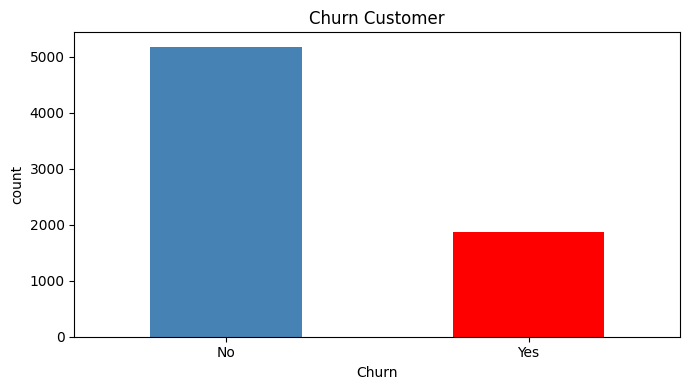

In [7]:
plt.figure(figsize=(7,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'red'])
plt.title('Churn Customer')
plt.xlabel('Churn')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Graph 2: Contract Type vs Churn**

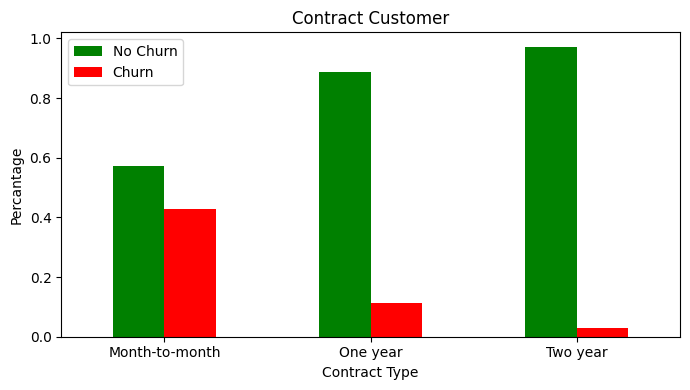

In [8]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn.plot(kind='bar', color=['green', 'red'], figsize=(7, 4))
plt.title('Contract Customer')
plt.xticks(rotation=0)
plt.xlabel('Contract Type')
plt.ylabel('Percantage')
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**Graph 3: Monthly Charges vs Churn**

In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


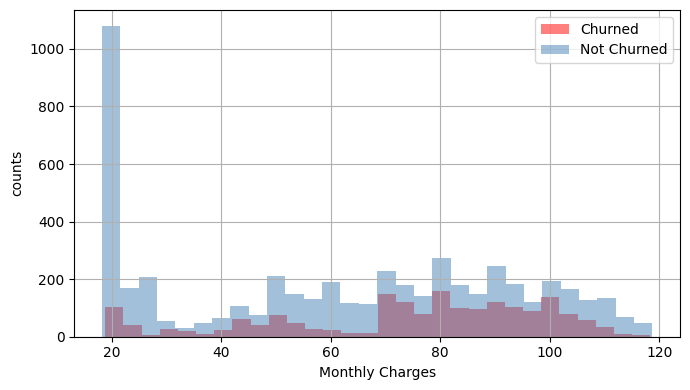

In [11]:
plt.figure(figsize=(7,4))
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(bins=30, alpha=0.5, color='red', label='Churned')
df[df['Churn'] == 'No']['MonthlyCharges'].hist(bins=30, alpha=0.5, color='steelblue', label='Not Churned')
plt.xlabel('Monthly Charges')
plt.ylabel('counts')
plt.legend()
plt.tight_layout()
plt.show()

**Graph 4: Tenure vs Churn**

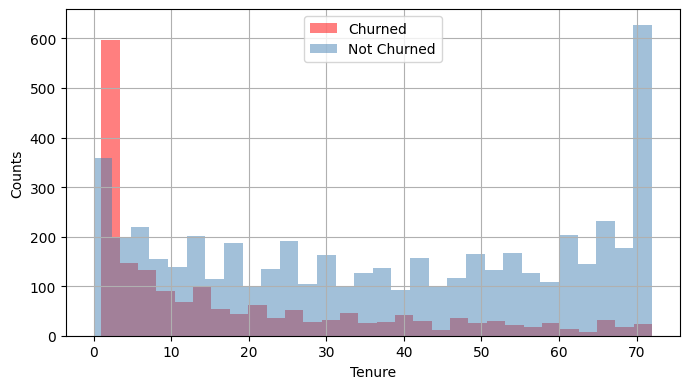

In [12]:
plt.figure(figsize=(7,4))
df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.5, color='red', label='Churned')
df[df['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.5, color='steelblue', label='Not Churned')
plt.xlabel('Tenure')
plt.ylabel('Counts')
plt.legend()
plt.tight_layout()
plt.show()

____________________

**DATA CLEANING**

In [13]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [14]:
print("Total dtype: ", df['TotalCharges'].dtype)
print("Missing Value: ", df['TotalCharges'].isnull().sum())

Total dtype:  float64
Missing Value:  11


In [15]:
df = df.dropna()
print("Shape after Dropping: ", df.shape)

Shape after Dropping:  (7032, 21)


Drop Useless Column

In [16]:
df = df.drop(columns=['customerID'])
print("Shape: ", df.shape)

Shape:  (7032, 20)


**Target Variable**

In [17]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No':0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [18]:
cat_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'gender'
]

binary_cols = []
multi_cols = []

for col in cat_cols:
  if df[col].nunique() == 2:
    binary_cols.append(col)

  else:
    multi_cols.append(col)


print("Binary Columns: ", binary_cols)
print("Multi Columns: ", multi_cols)


Binary Columns:  ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']
Multi Columns:  ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [19]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

yes_no_col = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in yes_no_col:
  df[col] = df[col].map({'Yes': 1, 'No': 0})

In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


**Final Check**

In [21]:
print("Shape: ", df.shape)
print("Null Value: ", df.isnull().sum().sum())
print("--"*15)
print(df.dtypes)

Shape:  (7032, 20)
Null Value:  0
------------------------------
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


_______________________

**Feature Engineering**

In [22]:
text_cols = df.select_dtypes(include=['object'])
text_cols.head()

,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Electronic check
1,No,DSL,Yes,No,Yes,No,No,No,One year,Mailed check
2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Mailed check
3,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,Bank transfer (automatic)
4,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check


In [23]:
for col in text_cols:
  print(f"\n{col}:", df[col].unique())


MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [24]:
text_cols.columns

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')

In [25]:
internet_cols = ['OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for cols in internet_cols:
  df[cols] = df[cols].replace("No internet service", "No")

In [26]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

In [27]:
print("MultipleLines Unique: ", df['MultipleLines'].unique())
print("OnlineSecurity Unique: ", df['OnlineSecurity'].unique())

MultipleLines Unique:  ['No' 'Yes']
OnlineSecurity Unique:  ['No' 'Yes']


**Convert Binary Number**



In [28]:
more_binary_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


for cols in more_binary_cols:
  df[cols] = df[cols].map({'Yes': 1, 'No':0})

In [29]:
print("Binary Columns")
print(df[more_binary_cols].head())

Binary Columns
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   
3              0               1             0                 1            1   
4              0               0             0                 0            0   

   StreamingTV  StreamingMovies  
0            0                0  
1            0                0  
2            0                0  
3            0                0  
4            0                0  


In [30]:
df = pd.get_dummies(df, columns=['InternetService',
                                  'Contract',
                                  'PaymentMethod'],
                    drop_first=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7032, 24)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [31]:
df['AvgMonthlySpend'] = df['MonthlyCharges']/df['tenure'].replace(0,1)
print(df['AvgMonthlySpend'].describe())

count    7032.000000
mean        8.620087
std        16.352057
min         0.268056
25%         1.277708
50%         2.147286
75%         6.611218
max       102.450000
Name: AvgMonthlySpend, dtype: float64


In [32]:
df["HighMonthlyCharge"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)
print(df["HighMonthlyCharge"].value_counts())

HighMonthlyCharge
0    3519
1    3513
Name: count, dtype: int64


In [33]:
# df["TenureGroup"] = pd.cut(
#     df["tenure"],
#     bins=[-1, 12, 36, 72],
#     labels=["New", "Medium", "Loyal"]
# )

In [34]:
# df["TenureGroup"] = df["TenureGroup"].map({
#     "New": 0,
#     "Medium": 1,
#     "Loyal": 2
# })

In [35]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    (df[service_cols] == "Yes")
    .sum(axis=1)
)

**Train/Test Split**

In [36]:
X = df.drop(columns = ['Churn'])
y = df['Churn']

print("X Shape: ", X.shape)
print("y Shape: ", y.shape)
print(y.value_counts())

X Shape:  (7032, 26)
y Shape:  (7032,)
Churn
0    5163
1    1869
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Model Training And Evaluation**

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report,  roc_auc_score, confusion_matrix, roc_curve, accuracy_score

In [39]:
print("Before SMOTE")
print(y_train.value_counts())

Before SMOTE
Churn
0    4130
1    1495
Name: count, dtype: int64


**Logistc Regression**

In [40]:
lr_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)


print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred,
      target_names=['stayed', 'churned']))

lr_auc = roc_auc_score(y_test,
         lr_pipeline.predict_proba(X_test)[:, 1])
print("LOGISTIC REGRESSION ROC-AUC Score:", round(lr_auc, 4))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

      stayed       0.86      0.82      0.84      1033
     churned       0.56      0.64      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.78      1407

LOGISTIC REGRESSION ROC-AUC Score: 0.8145


In [41]:
print("Firs 10 Prediction: ", lr_pred[:10])
print("Actual Values ", y_test.values[:10])

Firs 10 Prediction:  [0 0 0 0 0 1 0 0 1 0]
Actual Values  [0 0 0 1 0 1 0 0 1 0]


Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression')

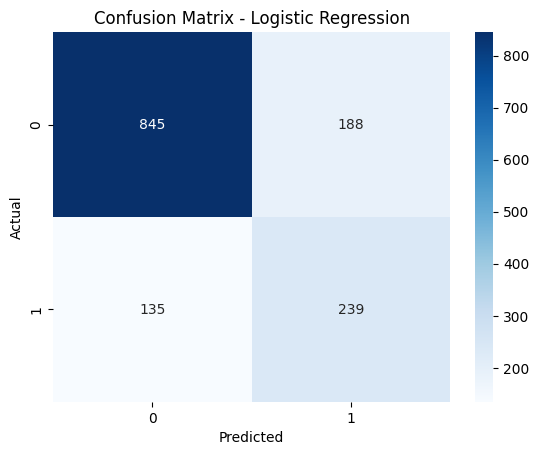

In [42]:
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d',  cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.title('Confusion Matrix - Logistic Regression')

**Random Forest Classifier**

In [43]:
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42,
                                     n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)


In [44]:
print("RANDOM FOREST")
print(classification_report(y_test, rf_pred,
      target_names=['Stayed', 'Churned']))

rf_auc = roc_auc_score(y_test,
         rf_pipeline.predict_proba(X_test)[:, 1])


print("RANDOM FOREST ROC-AUC Score:", round(rf_auc, 4))

RANDOM FOREST
              precision    recall  f1-score   support

      Stayed       0.85      0.82      0.84      1033
     Churned       0.56      0.61      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407

RANDOM FOREST ROC-AUC Score: 0.8063


**XGBClassifier**

In [45]:
xgb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

In [46]:
print("XGBClassifier Report")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Stayed', 'Churned']))

xgb_auc = roc_auc_score(y_test,
         xgb_pipeline.predict_proba(X_test)[:, 1])


print("XGBClassifier ROC-AUC Score:", round(xgb_auc, 4))

XGBClassifier Report
              precision    recall  f1-score   support

      Stayed       0.86      0.80      0.83      1033
     Churned       0.54      0.66      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407

XGBClassifier ROC-AUC Score: 0.8234


**ROC Curve**

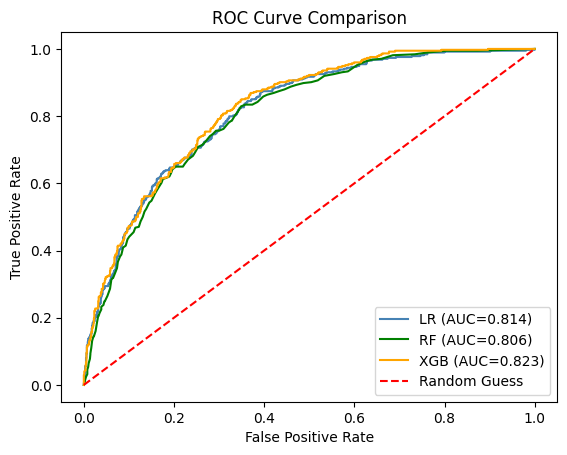

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pipeline.predict_proba(X_test)[:,1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pipeline.predict_proba(X_test)[:,1])
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pipeline.predict_proba(X_test)[:,1])


plt.plot(lr_fpr, lr_tpr, label=f'LR (AUC={round(lr_auc,3)})', color='steelblue')
plt.plot(rf_fpr, rf_tpr, label=f'RF (AUC={round(rf_auc,3)})', color='green')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGB (AUC={round(xgb_auc,3)})', color='orange')
plt.plot([0,1],[0,1], 'r--', label='Random Guess')


plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**Cross Validation**

In [48]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_scores = cross_val_score(
    xgb_pipeline, X_train, y_train,
    cv=cv, scoring='roc_auc'
)

print("AUC per fold:", xgb_scores.round(4))
print("Mean AUC:", round(xgb_scores.mean(), 4))
print("Std Dev:", round(xgb_scores.std(), 4))

AUC per fold: [0.8282 0.8315 0.8307 0.8378 0.8436]
Mean AUC: 0.8344
Std Dev: 0.0056


**Hyperparameter Tuning**

In [50]:
from sklearn.model_selection import RandomizedSearchCV

In [51]:
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__scale_pos_weight': [1, 2, 3]
}

search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print("Best AUC:", round(search.best_score_, 4))
print("Best Params:", search.best_params_)

Best AUC: 0.8346
Best Params: {'model__scale_pos_weight': 1, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.05}


**Threshold Optimization**

In [52]:
from sklearn.metrics import precision_recall_curve

best_xgb = search.best_estimator_
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]

print("Best Threshold:", round(best_threshold, 3))

y_pred_optimized = (xgb_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimized,
      target_names=['Stayed', 'Churned']))

Best Threshold: 0.383
              precision    recall  f1-score   support

      Stayed       0.90      0.73      0.80      1033
     Churned       0.51      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



In [53]:
test_auc = roc_auc_score(y_test, xgb_proba)
print("Test ROC-AUC:", round(test_auc, 4))

Test ROC-AUC: 0.8238
